In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("../data/processed_telomere_core.csv")
data.head()

,SEQN,TELOMEAN,TELOSTD,HorvathTelo,RIDAGEYR,qPCR_age_pred,qPCR_residual,DNAm_age_pred,DNAm_residual,qPCR_z,DNAm_z,discordance_signed,discordance,TELO_CV
0,2084.0,0.389337,0.027500,6.016263,76.0,0.869977,-0.480640,6.389530,-0.373267,-2.201683,-1.462034,-0.739649,0.739649,0.070632
1,6445.0,0.433244,0.018915,5.608514,81.0,0.841543,-0.408299,6.298962,-0.690448,-1.870308,-2.704391,0.834083,0.834083,0.043659
2,5363.0,0.443293,0.041010,5.970685,81.0,0.841543,-0.398250,6.298962,-0.328277,-1.824275,-1.285817,-0.538458,0.538458,0.092513
3,8606.0,0.444447,0.046839,5.903165,78.0,0.858603,-0.414156,6.353303,-0.450137,-1.897136,-1.763126,-0.134010,0.134010,0.105386
4,5843.0,0.453036,0.015954,6.119856,56.0,0.983713,-0.530677,6.751799,-0.631943,-2.430887,-2.475235,0.044348,0.044348,0.035217


In [2]:
cbc_a = pd.read_sas("../data/LAB25.xpt")
cbc_b = pd.read_sas("../data/L25_B.xpt")

In [3]:
print(cbc_a.columns.tolist())
print(cbc_b.columns.tolist())

['SEQN', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LBDMONO', 'LBDNENO', 'LBDEONO', 'LBDBANO', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXMCVSI', 'LBXMCHSI', 'LBXMC', 'LBXRDW', 'LBXPLTSI', 'LBXMPSI']
['SEQN', 'LBXWBCSI', 'LBXLYPCT', 'LBXMOPCT', 'LBXNEPCT', 'LBXEOPCT', 'LBXBAPCT', 'LBDLYMNO', 'LBDMONO', 'LBDNENO', 'LBDEONO', 'LBDBANO', 'LBXRBCSI', 'LBXHGB', 'LBXHCT', 'LBXMCVSI', 'LBXMCHSI', 'LBXMC', 'LBXRDW', 'LBXPLTSI', 'LBXMPSI']


In [4]:
cbc_columns = [
    "SEQN",
    "LBXWBCSI", 
    "LBXLYPCT",  # lymphocyte %
    "LBXMOPCT",  # monocyte %
    "LBXNEPCT",  # neutrophil %
    "LBXEOPCT",  # eosinophil %
    "LBXBAPCT"   
]

In [5]:
cbc_b[cbc_columns].head()

,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT
0,9966.0,9.9,23.2,9.4,63.5,3.1,0.9
1,9967.0,4.9,42.7,10.0,41.3,5.3,0.8
2,9968.0,9.4,23.1,8.9,65.6,1.7,0.8
3,9969.0,5.7,15.9,6.4,73.9,3.3,0.4
4,9970.0,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
cbc_all = pd.concat(
    [cbc_a[cbc_columns], cbc_b[cbc_columns]],
    ignore_index=True
)

In [7]:
cbc_all["SEQN"].duplicated().sum()

np.int64(0)

In [8]:
data_cbc = pd.merge(
    data,
    cbc_all,
    on="SEQN",
    how="left"
)

data_cbc.shape

(2530, 20)

In [9]:
data_cbc[cbc_columns[1:]].isna().sum()

LBXWBCSI     3
LBXLYPCT    13
LBXMOPCT    13
LBXNEPCT    13
LBXEOPCT    13
LBXBAPCT    13
dtype: int64

In [10]:
data_cbc = data_cbc.rename(columns={
    "LBXWBCSI": "WBC",
    "LBXLYPCT": "lymphocyte_pct",
    "LBXMOPCT": "monocyte_pct",
    "LBXNEPCT": "neutrophil_pct",
    "LBXEOPCT": "eosinophil_pct",
    "LBXBAPCT": "basophil_pct"
})

In [11]:
cbc_vars = [
    "WBC",
    "lymphocyte_pct",
    "monocyte_pct",
    "neutrophil_pct",
    "eosinophil_pct",
    "basophil_pct"
]

data_cbc[cbc_vars].describe()

,WBC,lymphocyte_pct,monocyte_pct,neutrophil_pct,eosinophil_pct,basophil_pct
count,2527.000000,2517.000000,2517.000000,2517.000000,2.517000e+03,2.517000e+03
mean,6.955520,29.917163,8.417521,58.081526,2.970679e+00,6.511323e-01
std,1.986526,8.821181,2.260993,9.638175,2.385780e+00,4.084896e-01
min,2.300000,5.300000,1.300000,20.400000,5.397605e-79,5.397605e-79
25%,5.600000,23.800000,6.900000,51.800000,1.600000e+00,4.000000e-01
50%,6.700000,29.500000,8.100000,58.400000,2.400000e+00,6.000000e-01
75%,8.100000,35.600000,9.600000,64.700000,3.700000e+00,8.000000e-01
max,22.400000,73.400000,24.900000,90.300000,4.800000e+01,8.500000e+00


In [12]:
data_cbc[
    cbc_vars + ["discordance"]
].corr(method="spearman")["discordance"].sort_values()

WBC              -0.058065
lymphocyte_pct   -0.011593
eosinophil_pct   -0.007525
neutrophil_pct    0.004594
basophil_pct      0.018481
monocyte_pct      0.023267
discordance       1.000000
Name: discordance, dtype: float64

In [13]:
data_cbc[
    cbc_vars + ["discordance_signed"]
].corr(method="spearman")["discordance_signed"].sort_values()

basophil_pct         -0.021465
lymphocyte_pct       -0.008844
neutrophil_pct       -0.005704
eosinophil_pct        0.017622
WBC                   0.021509
monocyte_pct          0.043472
discordance_signed    1.000000
Name: discordance_signed, dtype: float64

In [14]:
crp_a = pd.read_sas("../data/LAB11.xpt")
crp_b = pd.read_sas("../data/L11_B.xpt")

In [15]:
crp_columns = [
    "SEQN",
    "LBXCRP"
]

In [16]:
crp_all = pd.concat(
    [crp_a[crp_columns], crp_b[crp_columns]],
     ignore_index=True
)

In [17]:
crp_all["SEQN"].duplicated().sum()

np.int64(0)

In [18]:
analysis_data = pd.merge(
    data_cbc,
    crp_all,
    on="SEQN",
    how="left"
)

analysis_data.shape

(2530, 21)

In [19]:
analysis_data[crp_columns[1]].isna().sum()

np.int64(0)

In [20]:
analysis_data = analysis_data.rename(
    columns={
        "LBXCRP":"CRP"
    })

In [21]:
analysis_data[["CRP", "discordance"]].corr(method="spearman")

,CRP,discordance
CRP,1.000000,0.007423
discordance,0.007423,1.000000


In [22]:
analysis_data[["CRP","discordance_signed"]].corr(method="spearman")

,CRP,discordance_signed
CRP,1.000000,-0.060933
discordance_signed,-0.060933,1.000000


In [23]:
bmx_a = pd.read_sas("../data/BMX.xpt")
bmx_b = pd.read_sas("../data/BMX_B.xpt")

In [24]:
bmx_columns = [
    "SEQN",
    "BMXBMI",
    "BMXWAIST"
]

In [25]:
bmx_all = pd.concat(
    [bmx_a[bmx_columns], bmx_b[bmx_columns]],
    ignore_index=True
)

In [26]:
bmx_all["SEQN"].duplicated().sum()

np.int64(0)

In [27]:
analysis_data = pd.merge(
    analysis_data,
    bmx_all,
    on="SEQN",
    how="left")

analysis_data.shape

(2530, 23)

In [28]:
analysis_data.columns.tolist()

['SEQN',
 'TELOMEAN',
 'TELOSTD',
 'HorvathTelo',
 'RIDAGEYR',
 'qPCR_age_pred',
 'qPCR_residual',
 'DNAm_age_pred',
 'DNAm_residual',
 'qPCR_z',
 'DNAm_z',
 'discordance_signed',
 'discordance',
 'TELO_CV',
 'WBC',
 'lymphocyte_pct',
 'monocyte_pct',
 'neutrophil_pct',
 'eosinophil_pct',
 'basophil_pct',
 'CRP',
 'BMXBMI',
 'BMXWAIST']

In [29]:
analysis_data[bmx_columns[1:]].isna().sum()

BMXBMI      117
BMXWAIST    117
dtype: int64

In [30]:
analysis_data[["BMXBMI","discordance"]].corr(method="spearman")

,BMXBMI,discordance
BMXBMI,1.000000,0.044394
discordance,0.044394,1.000000


In [31]:
analysis_data[["BMXWAIST","discordance"]].corr(method="spearman")

,BMXWAIST,discordance
BMXWAIST,1.000000,0.023626
discordance,0.023626,1.000000


In [32]:
analysis_data[["BMXBMI","discordance_signed"]].corr(method="spearman")

,BMXBMI,discordance_signed
BMXBMI,1.000000,-0.043503
discordance_signed,-0.043503,1.000000


In [33]:
analysis_data[["BMXWAIST","discordance_signed"]].corr(method="spearman")

,BMXWAIST,discordance_signed
BMXWAIST,1.000000,0.006931
discordance_signed,0.006931,1.000000


In [34]:
smq_a = pd.read_sas("../data/SMQ.xpt")
smq_b = pd.read_sas("../data/SMQ_B.xpt")

In [35]:
smq_a.columns.tolist()

['SEQN',
 'SMQ020',
 'SMD030',
 'SMQ040',
 'SMQ050Q',
 'SMQ050U',
 'SMD055',
 'SMD057',
 'SMD070',
 'SMD075',
 'SMD080',
 'SMD090',
 'SMD100BR',
 'SMD100FL',
 'SMD100MN',
 'SMD100LN',
 'SMD100TR',
 'SMD100NI',
 'SMD100CO',
 'SMQ120',
 'SMD130',
 'SMQ140',
 'SMQ143',
 'SMQ145',
 'SMQ150',
 'SMD160',
 'SMQ170',
 'SMQ173',
 'SMQ175',
 'SMQ180',
 'SMD190',
 'SMQ200',
 'SMD203',
 'SMQ205',
 'SMQ210',
 'SMD220',
 'SMQ230',
 'SMD233',
 'SMD235']

In [36]:
smk_columns = [
    "SEQN",
    "SMQ020",
    "SMQ040",
    "SMD070"
]

In [37]:
smk_all = pd.concat(
    [smq_a[smk_columns], smq_b[smk_columns]],
    ignore_index=True
)

In [38]:
smk_all["SEQN"].duplicated().sum()

np.int64(0)

In [39]:
analysis_data = pd.merge(
    analysis_data,
    smk_all,
    on="SEQN",
    how="left"
)

In [40]:
analysis_data.shape

(2530, 26)

In [41]:
analysis_data[smk_columns[1:3]].isna().sum()

SMQ020       2
SMQ040    1174
dtype: int64

In [42]:
analysis_data["SMQ020"].value_counts(dropna=False)

SMQ020
1.0    1356
2.0    1168
9.0       4
NaN       2
Name: count, dtype: int64

In [43]:
analysis_data["SMQ040"].value_counts(dropna=False)

SMQ040
NaN    1174
3.0     968
1.0     336
2.0      52
Name: count, dtype: int64

In [44]:
analysis_data["SMD070"].value_counts(dropna=False)

SMD070
NaN      2194
20.0      104
10.0       57
15.0       25
40.0       20
30.0       18
5.0        15
4.0        12
1.0        12
3.0        10
7.0         8
2.0         8
18.0        6
8.0         6
12.0        6
6.0         5
25.0        4
9.0         4
16.0        3
60.0        2
50.0        2
65.0        1
26.0        1
34.0        1
14.0        1
22.0        1
11.0        1
45.0        1
999.0       1
35.0        1
Name: count, dtype: int64

In [45]:
analysis_data["smoking_status"] = pd.Series(
    pd.NA,
    index=analysis_data.index,
    dtype="string"
)

In [46]:
analysis_data.loc[
    analysis_data["SMQ020"] == 2,
    "smoking_status"
] = "never"

In [47]:
analysis_data.loc[
    (analysis_data["SMQ020"] == 1) &
    (analysis_data["SMQ040"] == 3),
    "smoking_status"
] = "former"

In [48]:
analysis_data.loc[
    (analysis_data["SMQ020"] == 1) &
    (analysis_data["SMQ040"].isin([1,2])),
    "smoking_status"
] = "current"

In [49]:
analysis_data["smoking_status"].value_counts(dropna=False)

smoking_status
never      1168
former      968
current     388
<NA>          6
Name: count, dtype: Int64

In [50]:
analysis_data.groupby("smoking_status")["discordance"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
smoking_status,,,
current,388,0.885806,0.676975
former,968,0.915166,0.753884
never,1168,0.929193,0.753921


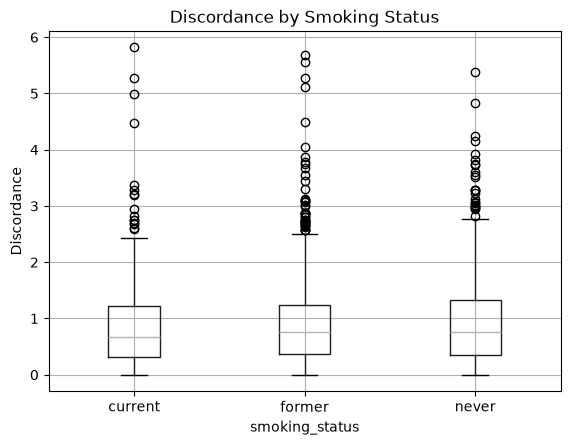

In [51]:
analysis_data.boxplot(
    column="discordance",
    by="smoking_status"
)
plt.ylabel("Discordance")
plt.title("Discordance by Smoking Status")
plt.suptitle("")
plt.show()

In [52]:
from scipy.stats import kruskal

current = analysis_data.loc[
    analysis_data["smoking_status"] == "current",
    "discordance"
].dropna()

former = analysis_data.loc[
    analysis_data["smoking_status"] == "former",
    "discordance"
].dropna()

never = analysis_data.loc[
    analysis_data["smoking_status"] == "never",
    "discordance"
].dropna()

kruskal(current, former, never)

KruskalResult(statistic=np.float64(2.5849564527170514), pvalue=np.float64(0.2745894443838468))

In [53]:
demo_a = pd.read_sas("../data/DEMO.xpt")
demo_b = pd.read_sas("../data/DEMO_B.xpt")

In [54]:
sex_all = pd.concat([
    demo_a[["SEQN", "RIAGENDR"]],
    demo_b[["SEQN", "RIAGENDR"]]
], ignore_index=True)

In [55]:
analysis_data = pd.merge(
    analysis_data,
    sex_all,
    on="SEQN",
    how="left"
)

In [56]:
analysis_data["RIAGENDR"].value_counts(dropna=False)

RIAGENDR
1.0    1283
2.0    1247
Name: count, dtype: int64

In [57]:
analysis_data["sex"] = analysis_data["RIAGENDR"].map({
    1: "male",
    2: "female"
})

In [58]:
analysis_data.groupby("sex")["discordance"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
sex,,,
female,1247,0.925876,0.750725
male,1283,0.909592,0.733113


In [59]:
analysis_data.groupby("sex")["discordance_signed"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
sex,,,
female,1247,-0.139375,-0.206253
male,1283,0.135464,0.081408


In [60]:
from scipy.stats import mannwhitneyu

male = analysis_data.loc[
    analysis_data["sex"] == "male",
    "discordance"
].dropna()

female = analysis_data.loc[
    analysis_data["sex"] == "female",
    "discordance"
].dropna()

mannwhitneyu(male, female)

MannwhitneyuResult(statistic=np.float64(791058.0), pvalue=np.float64(0.6283446698188473))

In [61]:
male = analysis_data.loc[
    analysis_data["sex"] == "male",
    "discordance_signed"
].dropna()

female = analysis_data.loc[
    analysis_data["sex"] == "female",
    "discordance_signed"
].dropna()

mannwhitneyu(male, female)

MannwhitneyuResult(statistic=np.float64(915663.0), pvalue=np.float64(2.99437843626773e-10))

In [62]:
current = analysis_data.loc[
    analysis_data["smoking_status"] == "current",
    "discordance_signed"
].dropna()

former = analysis_data.loc[
    analysis_data["smoking_status"] == "former",
    "discordance_signed"
].dropna()

never = analysis_data.loc[
    analysis_data["smoking_status"] == "never",
    "discordance_signed"
].dropna()

kruskal(current, former, never)

KruskalResult(statistic=np.float64(34.42059754806087), pvalue=np.float64(3.354765827489523e-08))

In [63]:
analysis_data.groupby("smoking_status")["discordance_signed"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
smoking_status,,,
current,388,0.251237,0.094747
former,968,0.063021,-0.001042
never,1168,-0.134098,-0.162432


In [64]:
pd.crosstab(
    analysis_data["smoking_status"],
    analysis_data["sex"],
    normalize="index"
)

sex,female,male
smoking_status,,
current,0.391753,0.608247
former,0.349174,0.650826
never,0.644692,0.355308


In [65]:
analysis_data.groupby(
    ["sex", "smoking_status"]
)["discordance_signed"].agg(
    ["count", "mean", "median"]
)

count      mean    median
sex    smoking_status                           
female current           152  0.070340 -0.124124
       former            338 -0.076080 -0.165563
       never             753 -0.208449 -0.236171
male   current           236  0.367748  0.263976
       former            630  0.137650  0.053268
       never             415  0.000810 -0.034360

In [66]:
analysis_data[
    ["BMXBMI", "BMXWAIST", "discordance", "discordance_signed"]
].corr(method="spearman")

,BMXBMI,BMXWAIST,discordance,discordance_signed
BMXBMI,1.000000,0.857318,0.044394,-0.043503
BMXWAIST,0.857318,1.000000,0.023626,0.006931
discordance,0.044394,0.023626,1.000000,-0.017080
discordance_signed,-0.043503,0.006931,-0.017080,1.000000


In [67]:
analysis_data[
    ["TELOSTD", "TELO_CV", "discordance", "discordance_signed"]
].corr(method="spearman")

,TELOSTD,TELO_CV,discordance,discordance_signed
TELOSTD,1.000000,0.841435,0.062812,0.270044
TELO_CV,0.841435,1.000000,0.022503,0.005029
discordance,0.062812,0.022503,1.000000,-0.017080
discordance_signed,0.270044,0.005029,-0.017080,1.000000


In [68]:
analysis_data[
    ["TELOMEAN", "TELOSTD", "TELO_CV", "qPCR_z"]
].corr(method="spearman")

,TELOMEAN,TELOSTD,TELO_CV,qPCR_z
TELOMEAN,1.000000,0.464133,-0.032913,0.955840
TELOSTD,0.464133,1.000000,0.841435,0.445684
TELO_CV,-0.032913,0.841435,1.000000,-0.032732
qPCR_z,0.955840,0.445684,-0.032732,1.000000


In [69]:
hba_a = pd.read_sas("../data/LAB10.xpt")
hba_b = pd.read_sas("../data/L10_B.xpt")

In [70]:
hba_columns = ["SEQN", "LBXGH"]

In [71]:
hba_all = pd.concat(
    [
        hba_a[hba_columns], hba_b[hba_columns]
    ],
    ignore_index=True
)

In [72]:
hba_all["SEQN"].duplicated().sum()

np.int64(0)

In [73]:
analysis_data = pd.merge(
    analysis_data,
    hba_all,
    on="SEQN",
    how="left"
)

analysis_data.shape

(2530, 30)

In [74]:
analysis_data = analysis_data.rename(
    columns={
        "LBXGH": "HbA1c"
    }
)

In [75]:
analysis_data[
    ["HbA1c",  "discordance", "discordance_signed"]
].corr(method="spearman")

,HbA1c,discordance,discordance_signed
HbA1c,1.000000,-0.030818,0.019912
discordance,-0.030818,1.000000,-0.017080
discordance_signed,0.019912,-0.017080,1.000000


In [76]:
analysis_data.shape

(2530, 30)

In [77]:
analysis_data["SEQN"].duplicated().sum()

np.int64(0)

In [78]:
[
    col for col in analysis_data.columns
    if col.endswith(("_x", "_y"))
]

[]

In [79]:
feature_columns = [
    # CBC
    "WBC",
    "lymphocyte_pct",
    "monocyte_pct",
    "neutrophil_pct",
    "eosinophil_pct",
    "basophil_pct",

    # inflammation
    "CRP",

    # adiposity
    "BMXBMI",
    "BMXWAIST",

    # categorical features
    "smoking_status",
    "sex",

    # metabolism
    "HbA1c"
]

In [80]:
target_columns = [
    "discordance",
    "discordance_signed"
]

In [81]:
model_data = analysis_data[
    ["SEQN"] + feature_columns + target_columns
].copy()

In [82]:
model_data.shape

(2530, 15)

In [83]:
model_data.isna().sum().sort_values(ascending=False)

BMXBMI                117
BMXWAIST              117
lymphocyte_pct         13
monocyte_pct           13
neutrophil_pct         13
eosinophil_pct         13
basophil_pct           13
smoking_status          6
WBC                     3
HbA1c                   1
SEQN                    0
CRP                     0
sex                     0
discordance             0
discordance_signed      0
dtype: int64

In [84]:
model_data.dtypes

SEQN                         float64
WBC                          float64
lymphocyte_pct               float64
monocyte_pct                 float64
neutrophil_pct               float64
eosinophil_pct               float64
basophil_pct                 float64
CRP                          float64
BMXBMI                       float64
BMXWAIST                     float64
smoking_status        string[python]
sex                           object
HbA1c                        float64
discordance                  float64
discordance_signed           float64
dtype: object

In [85]:
analysis_data["sex"] = analysis_data["sex"].astype("string")

In [86]:
qc_data = analysis_data[
    ["SEQN", "TELOSTD", "TELO_CV"]
].copy()

In [87]:
model_data.to_csv(
    "../data/telomere_model_features.csv",
    index=False
)

qc_data.to_csv(
    "../data/telomere_qc_features.csv",
    index=False
)

In [88]:
analysis_data.to_csv(
    "../data/analysis_data.csv",
    index=False
)